## Importing libraries

In [1]:
import numpy as np
import pandas as pd

## Loading Dataset
- datasetlink :- https://www.kaggle.com/datasets/rajsengo/indian-premier-league-ipl-all-seasons?select=all_season_batting_card.csv

In [2]:
df=pd.read_csv("all_season_batting_card.csv")

# knowing what are the columns in the dataset

In [3]:
df.columns

Index(['season', 'match_id', 'match_name', 'home_team', 'away_team', 'venue',
       'city', 'country', 'current_innings', 'innings_id', 'name', 'fullName',
       'runs', 'ballsFaced', 'minutes', 'fours', 'sixes', 'strikeRate',
       'captain', 'isNotOut', 'runningScore', 'runningOver', 'shortText',
       'commentary', 'link'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15720 entries, 0 to 15719
Data columns (total 25 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   season           15684 non-null  float64
 1   match_id         15720 non-null  int64  
 2   match_name       15720 non-null  object 
 3   home_team        15720 non-null  object 
 4   away_team        15720 non-null  object 
 5   venue            15720 non-null  object 
 6   city             15720 non-null  object 
 7   country          15720 non-null  object 
 8   current_innings  15720 non-null  object 
 9   innings_id       15720 non-null  int64  
 10  name             15720 non-null  object 
 11  fullName         15720 non-null  object 
 12  runs             15714 non-null  float64
 13  ballsFaced       15714 non-null  float64
 14  minutes          15714 non-null  object 
 15  fours            15714 non-null  float64
 16  sixes            15714 non-null  float64
 17  strikeRate  

In [5]:
df.shape

(15720, 25)

#  Checking Missing Values

In [6]:
df.isnull().sum()

season                36
match_id               0
match_name             0
home_team              0
away_team              0
venue                  0
city                   0
country                0
current_innings        0
innings_id             0
name                   0
fullName               0
runs                   6
ballsFaced             6
minutes                6
fours                  6
sixes                  6
strikeRate             6
captain                0
isNotOut               6
runningScore           6
runningOver         3691
shortText              0
commentary          3694
link               15720
dtype: int64

# Removing unimpotant  Columns

In [7]:
df.drop(columns=['link'], inplace=True)
df.columns

Index(['season', 'match_id', 'match_name', 'home_team', 'away_team', 'venue',
       'city', 'country', 'current_innings', 'innings_id', 'name', 'fullName',
       'runs', 'ballsFaced', 'minutes', 'fours', 'sixes', 'strikeRate',
       'captain', 'isNotOut', 'runningScore', 'runningOver', 'shortText',
       'commentary'],
      dtype='object')

# Handling Missing Values Numerical Columns

In [8]:
df['runs'] = df['runs'].fillna(df['runs'].mean())
df['ballsFaced'] = df['ballsFaced'].fillna(df['ballsFaced'].mean())
df['fours'] = df['fours'].fillna(df['fours'].mean())
df['sixes'] = df['sixes'].fillna(df['sixes'].mean())

# Handling Missing value categorical columns

In [9]:
df['isNotOut'] = df['isNotOut'].fillna('Unknown')
df['runningScore'] = df['runningScore'].fillna('0')

# Dropping columns with too many missing values

In [10]:
df.drop(columns=['commentary', 'runningOver'], errors='ignore', inplace=True)
df.columns

Index(['season', 'match_id', 'match_name', 'home_team', 'away_team', 'venue',
       'city', 'country', 'current_innings', 'innings_id', 'name', 'fullName',
       'runs', 'ballsFaced', 'minutes', 'fours', 'sixes', 'strikeRate',
       'captain', 'isNotOut', 'runningScore', 'shortText'],
      dtype='object')

# Converting Data Types

In [11]:
df['strikeRate'] = pd.to_numeric(df['strikeRate'], errors='coerce')
df.dtypes

season             float64
match_id             int64
match_name          object
home_team           object
away_team           object
venue               object
city                object
country             object
current_innings     object
innings_id           int64
name                object
fullName            object
runs               float64
ballsFaced         float64
minutes             object
fours              float64
sixes              float64
strikeRate         float64
captain               bool
isNotOut            object
runningScore        object
shortText           object
dtype: object

# One Final Data Cleaning Check

In [12]:
df.isnull().sum()

season              36
match_id             0
match_name           0
home_team            0
away_team            0
venue                0
city                 0
country              0
current_innings      0
innings_id           0
name                 0
fullName             0
runs                 0
ballsFaced           0
minutes              6
fours                0
sixes                0
strikeRate         324
captain              0
isNotOut             0
runningScore         0
shortText            0
dtype: int64

# Handling Remaining Missing Value

In [13]:
df = df.dropna(subset=['minutes'])
df['strikeRate'] = df['strikeRate'].fillna(df['strikeRate'].mean())
df = df.dropna(subset=['season'])

In [14]:
df.isnull().sum()

season             0
match_id           0
match_name         0
home_team          0
away_team          0
venue              0
city               0
country            0
current_innings    0
innings_id         0
name               0
fullName           0
runs               0
ballsFaced         0
minutes            0
fours              0
sixes              0
strikeRate         0
captain            0
isNotOut           0
runningScore       0
shortText          0
dtype: int64

# Exploratory Data Analysis (EDA)
## importing Data Visualization Libraries

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of Runs 

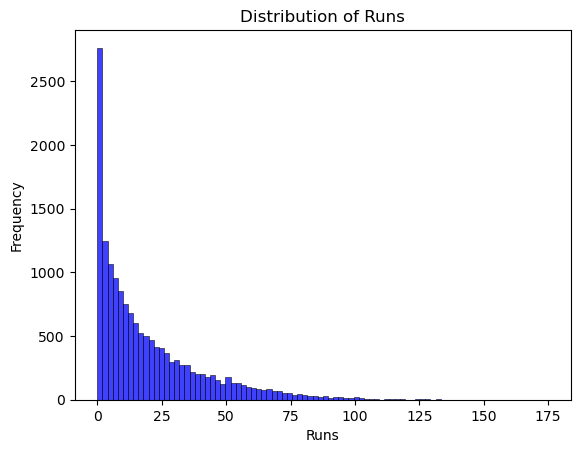

In [16]:
plt.figure()
sns.histplot(df['runs'],color='blue',edgecolor='black')
plt.title("Distribution of Runs")
plt.xlabel("Runs")
plt.ylabel("Frequency")
plt.show()

# No Of Matches Played by Teams

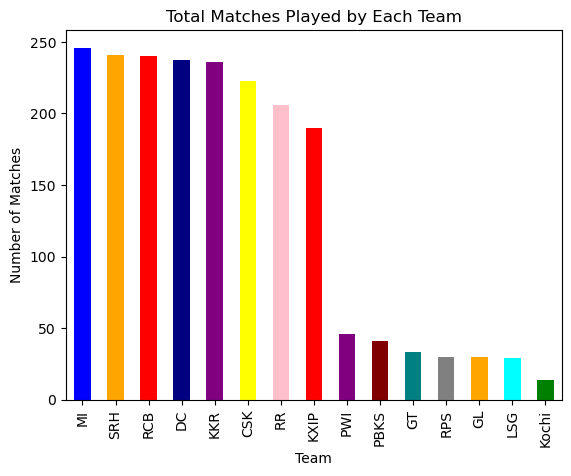

In [17]:
plt.figure()
teams = pd.concat([df[['match_id','home_team']].drop_duplicates()['home_team'],
                   df[['match_id','away_team']].drop_duplicates()['away_team']])
team_counts = teams.value_counts()
colors = ['blue','orange','red','navy','purple','yellow','pink','red','purple','maroon','teal','gray','orange','cyan','green']
team_counts.plot(kind='bar',color=colors)
plt.title("Total Matches Played by Each Team")
plt.xlabel("Team")
plt.ylabel("Number of Matches")
plt.xticks(rotation=90)
plt.show()

# Top Run scorers in ipl

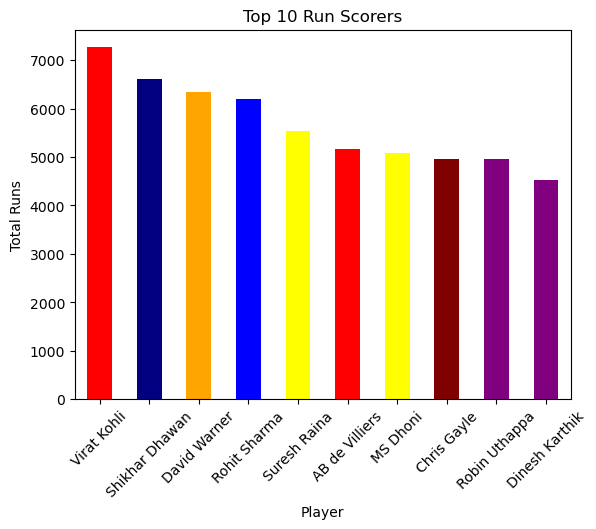

In [18]:
plt.figure()
top_players=df.groupby('fullName')['runs'].sum().sort_values(ascending=False).head(10)
colors=[
    'red','navy','orange','blue','yellow',
    'red','yellow','maroon','purple','purple'
]
top_players.plot(kind='bar',color=colors)
plt.title("Top 10 Run Scorers")
plt.xlabel("Player")
plt.ylabel("Total Runs")
plt.xticks(rotation=45)
plt.show()

# strike rate analysis of players

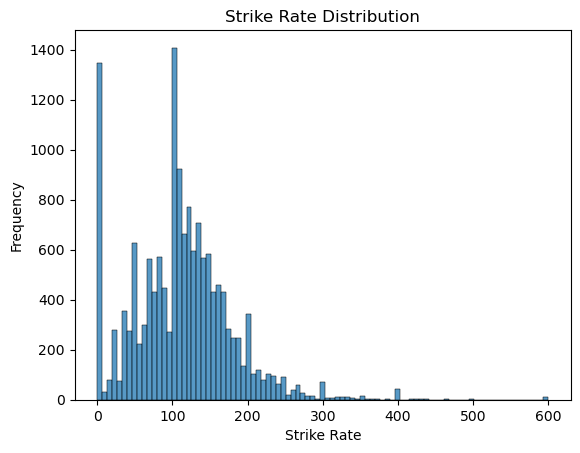

In [19]:
plt.figure()
sns.histplot(df['strikeRate'])
plt.title("Strike Rate Distribution")
plt.xlabel("Strike Rate")
plt.ylabel("Frequency")
plt.show()

# Runs vs Balls Faced

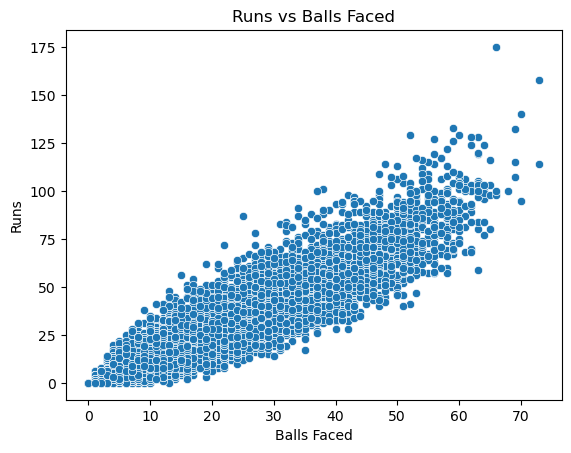

In [20]:
plt.figure()
sns.scatterplot(x=df['ballsFaced'],y=df['runs'])
plt.title("Runs vs Balls Faced")
plt.xlabel("Balls Faced")
plt.ylabel("Runs")
plt.show()

# correlation Heatmap relationship between variables

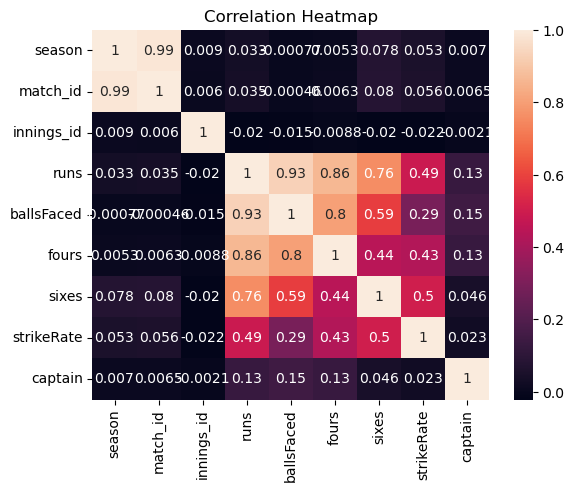

In [21]:
plt.figure()
corr=df.corr(numeric_only=True)
sns.heatmap(corr,annot=True)
plt.title("Correlation Heatmap")
plt.show()

# Pairplot Analysis

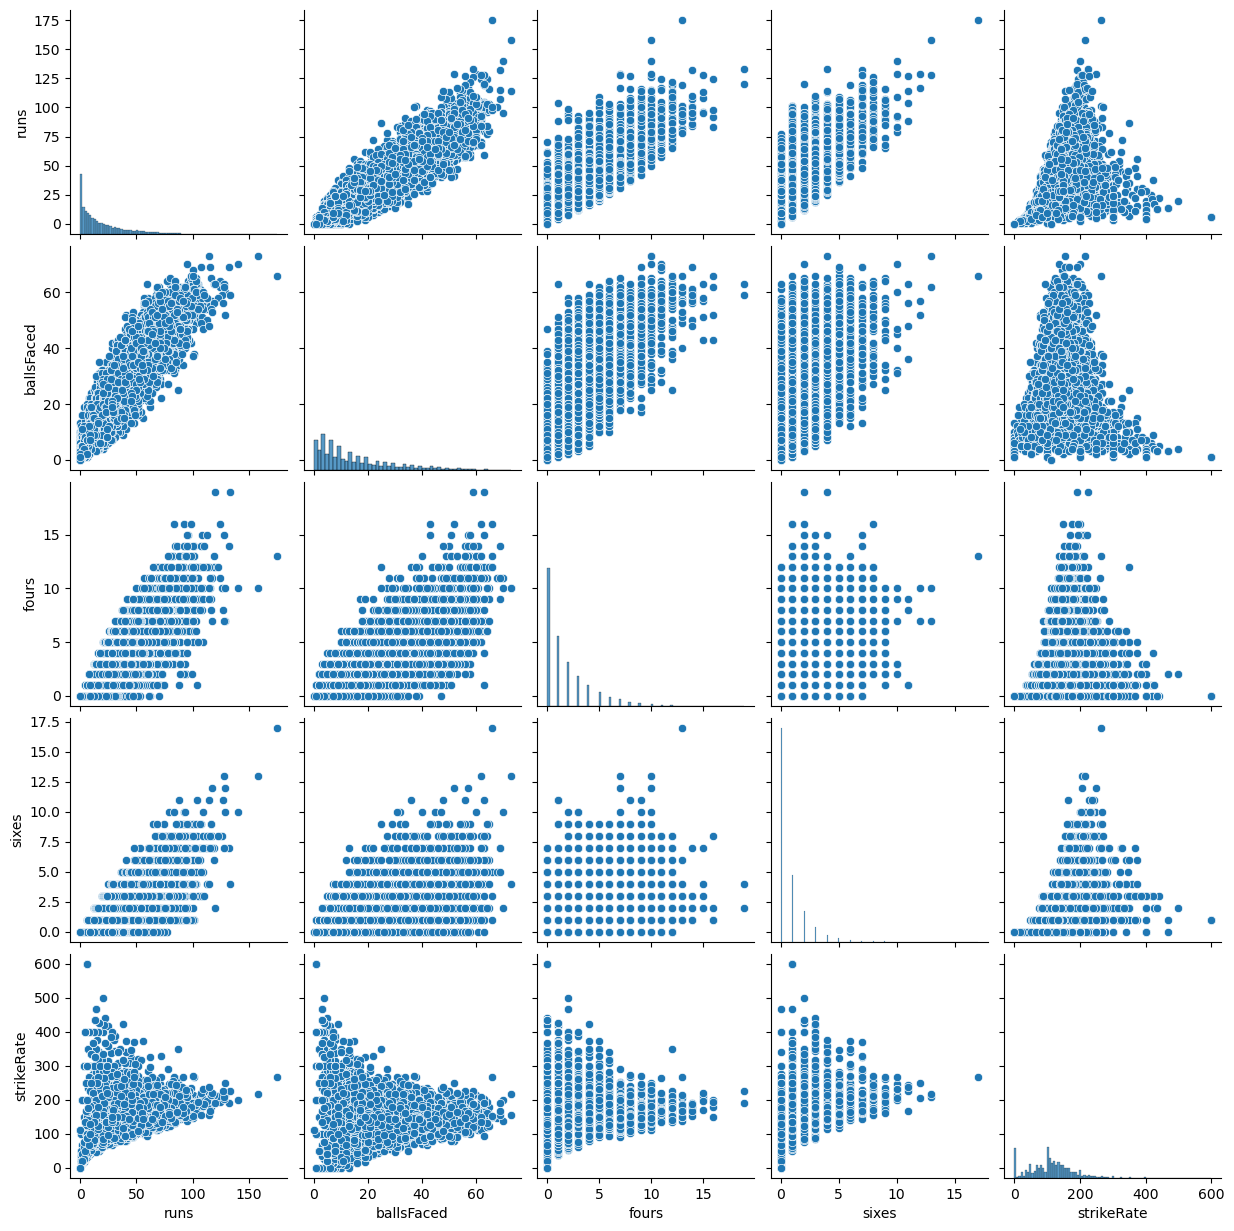

In [22]:
sns.pairplot(df[['runs','ballsFaced','fours','sixes','strikeRate']])
plt.show()

# Top Players by Strikerate minimum (500runs)

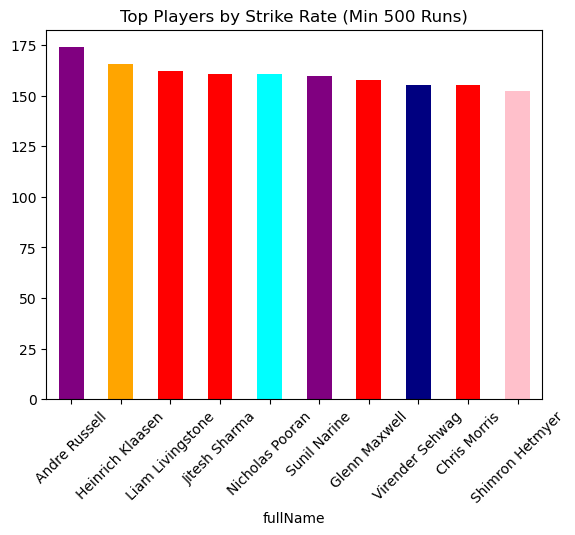

In [24]:
player_stats=df.groupby('fullName').agg({'runs':'sum','ballsFaced':'sum'})
player_stats['strikeRate']=(player_stats['runs']/player_stats['ballsFaced'])*100
top_sr=player_stats[player_stats['runs']>500].sort_values(by='strikeRate',ascending=False).head(10)
plt.figure()
player_colors={
    'Andre Russell':'purple',
    'Heinrich Klaasen':'orange',
    'Liam Livingstone':'red',
    'Jitesh Sharma':'red',
    'Nicholas Pooran':'cyan',
    'Sunil Narine':'purple',
    'Glenn Maxwell':'red',
    'Virender Sehwag':'navy',
    'Chris Morris':'red',
    'Shimron Hetmyer':'pink'
}
colors=[player_colors.get(p,'gray') for p in top_sr.index]
top_sr['strikeRate'].plot(kind='bar',color=colors)
plt.title("Top Players by Strike Rate (Min 500 Runs)")
plt.xticks(rotation=45)
plt.show()

# Boundary Contribution Analysis

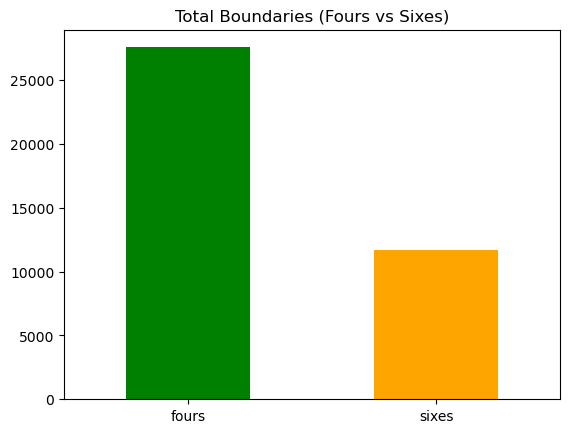

In [25]:
boundary=df[['fours','sixes']].sum()
plt.figure()
colors=['green','orange']
boundary.plot(kind='bar',color=colors)
plt.title("Total Boundaries (Fours vs Sixes)")
plt.xticks(rotation=0)
plt.show()

# Team Performance Analysis(runs)

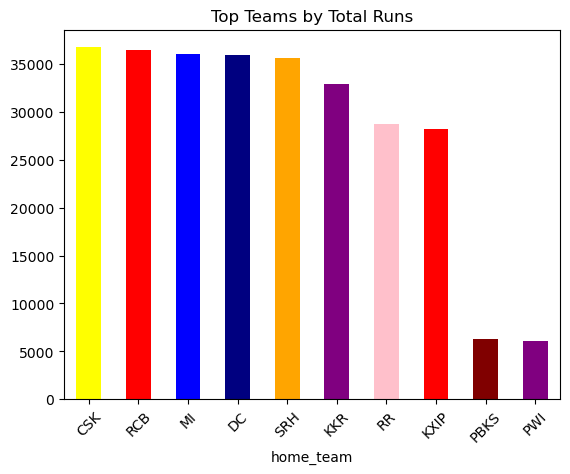

In [26]:
team_runs=df.groupby('home_team')['runs'].sum().sort_values(ascending=False)
plt.figure()
colors=['yellow','red','blue','navy','orange','purple','pink','red','maroon','purple']
team_runs.head(10).plot(kind='bar',color=colors)
plt.title("Top Teams by Total Runs")
plt.xticks(rotation=45)
plt.show()

# Player Consistency Analysis

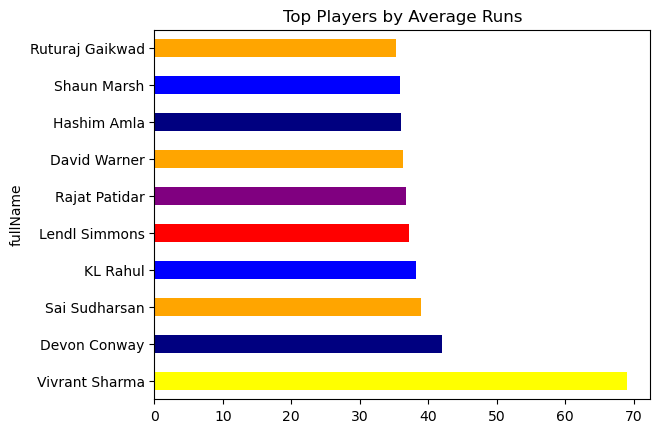

In [27]:
player_avg=df.groupby('fullName')['runs'].mean().sort_values(ascending=False).head(10)
plt.figure()
colors=['yellow','navy','orange','blue','red','purple','orange','navy','blue','orange']
player_avg.plot(kind='barh',color=colors)
plt.title("Top Players by Average Runs")
plt.show()

# Venue Analysis

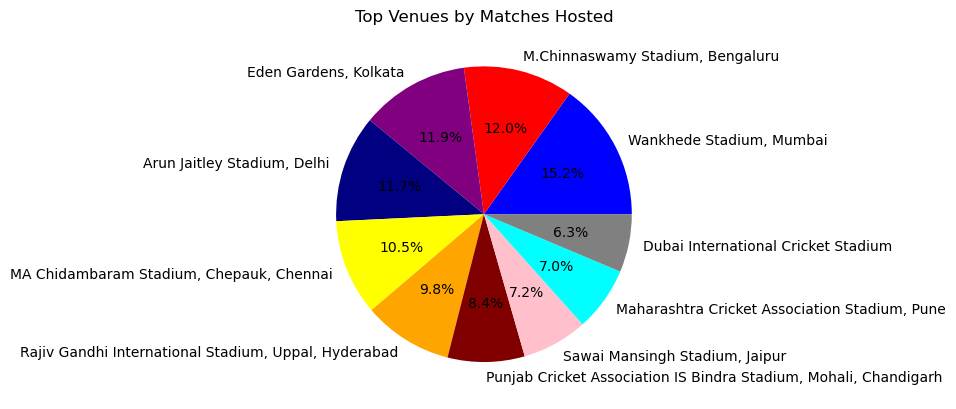

In [28]:
venue_counts=df[['match_id','venue']].drop_duplicates()['venue'].value_counts().head(10)
plt.figure()
plt.pie(venue_counts.values,labels=venue_counts.index,autopct='%1.1f%%',
        colors=['blue','red','purple','navy','yellow','orange','maroon','pink','cyan','gray'])
plt.title("Top Venues by Matches Hosted")
plt.show()

# Season-wise Runs Analysis

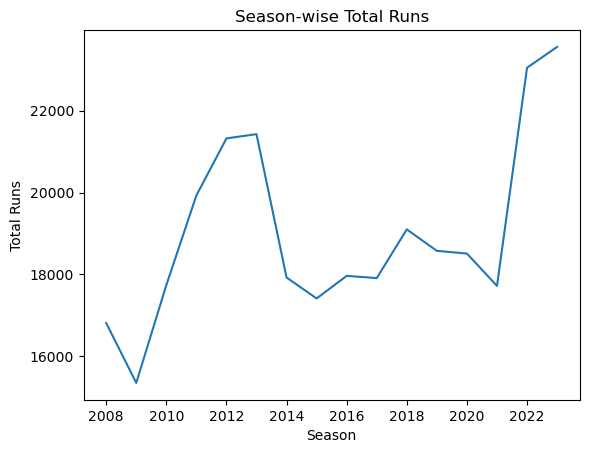

In [29]:
season_runs=df.groupby('season')['runs'].sum()
plt.figure()
season_runs.plot(kind='line')
plt.title("Season-wise Total Runs")
plt.xlabel("Season")
plt.ylabel("Total Runs")
plt.show()

# Captain Performance Analysis

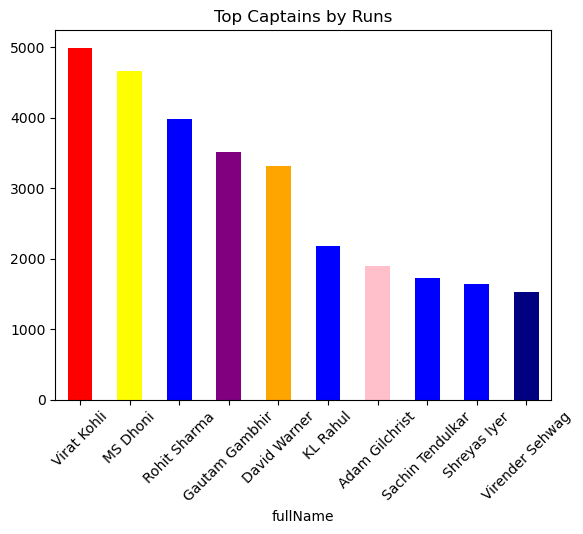

In [30]:
captain_runs=df[df['captain']==True].groupby('fullName')['runs'].sum().sort_values(ascending=False).head(10)
plt.figure()
captain_runs.plot(kind='bar',color=['red','yellow','blue','purple','orange','blue','pink','blue','blue','navy'])
plt.title("Top Captains by Runs")
plt.xticks(rotation=45)
plt.show()

# Top Boundary Hitters

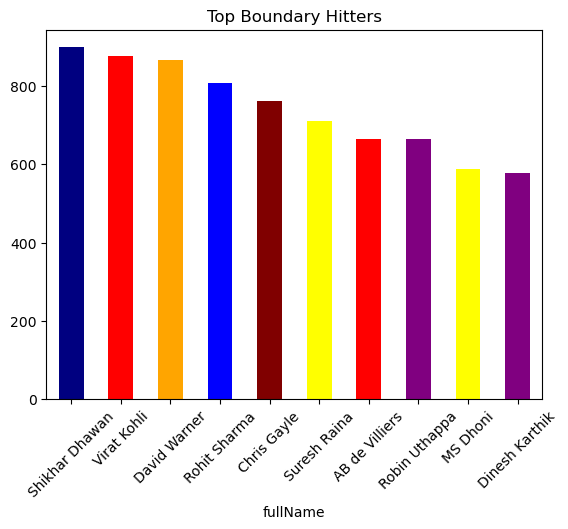

In [31]:
boundary_players=df.groupby('fullName')[['fours','sixes']].sum()
boundary_players['total_boundaries']=boundary_players['fours']+boundary_players['sixes']
top_boundary=boundary_players.sort_values(by='total_boundaries',ascending=False).head(10)
plt.figure()
top_boundary['total_boundaries'].plot(kind='bar',color=['navy','red','orange','blue','maroon','yellow','red','purple','yellow','purple'])
plt.title("Top Boundary Hitters")
plt.xticks(rotation=45)
plt.show()

# Sixes by Captains

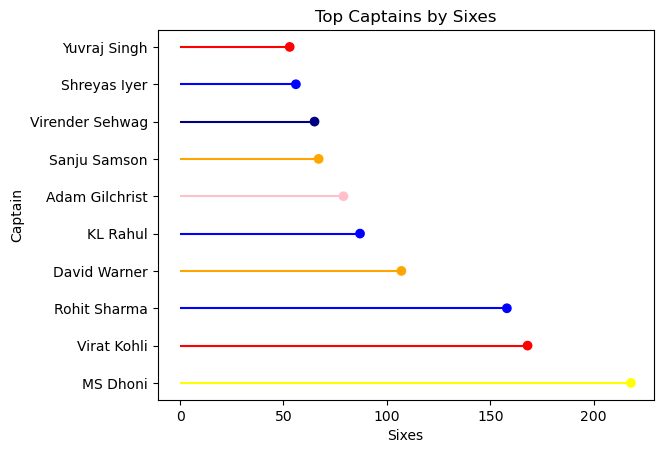

In [32]:
captain_sixes=df[df['captain']==True].groupby('fullName')['sixes'].sum().sort_values(ascending=False).head(10)
plt.figure()

colors=['yellow','red','blue','orange','blue','pink','orange','navy','blue','red']

plt.hlines(y=captain_sixes.index, xmin=0, xmax=captain_sixes.values, color=colors)
plt.scatter(captain_sixes.values, captain_sixes.index, color=colors)

plt.title("Top Captains by Sixes")
plt.xlabel("Sixes")
plt.ylabel("Captain")

plt.show()

# Runs vs Strike Rate (Top Players)

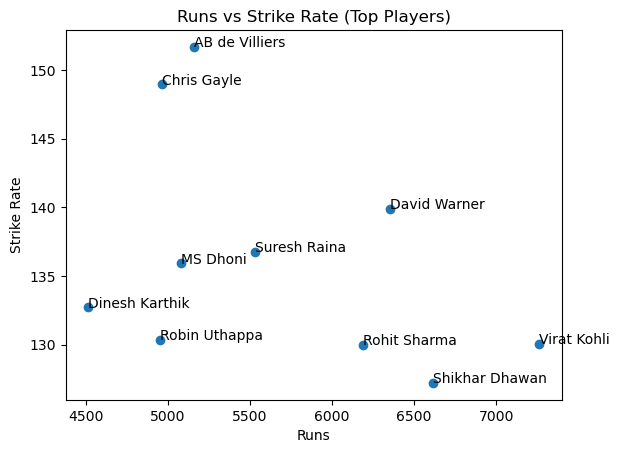

In [33]:
plt.figure()

top_players = (
    df.groupby('fullName')
    .agg(runs=('runs','sum'), ballsFaced=('ballsFaced','sum'))
)

top_players['strikeRate'] = (top_players['runs'] / top_players['ballsFaced']) * 100
top_players = top_players.sort_values(by='runs', ascending=False).head(10)

plt.scatter(top_players['runs'], top_players['strikeRate'])
plt.title("Runs vs Strike Rate (Top Players)")
plt.xlabel("Runs")
plt.ylabel("Strike Rate")

for i, txt in enumerate(top_players.index):
    plt.annotate(txt, (top_players['runs'].iloc[i], top_players['strikeRate'].iloc[i]))

plt.show()

# Calculating Winning Percentage
Winning percentage is calculated as:
Wins / Total Matches × 100

# Captains with Most Matches

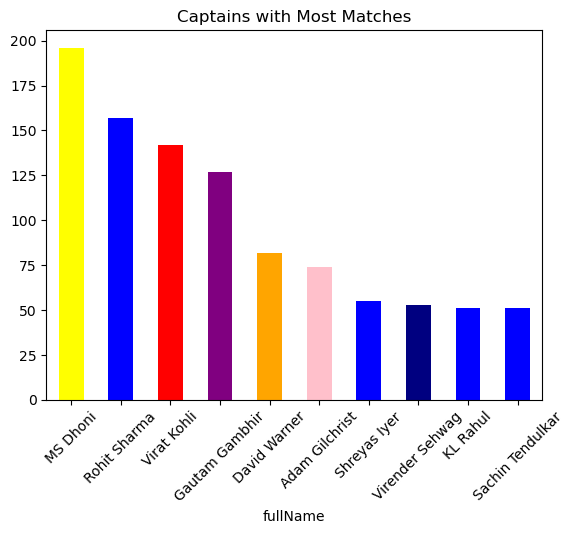

In [34]:
captain_matches=df[df['captain']==True]['fullName'].value_counts().head(10)
plt.figure()
captain_matches.plot(kind='bar',color=['yellow','blue','red','purple','orange','pink','blue','navy','blue','blue'])
plt.title("Captains with Most Matches")
plt.xticks(rotation=45)
plt.show()

# Clutch Players (High Impact Performers)

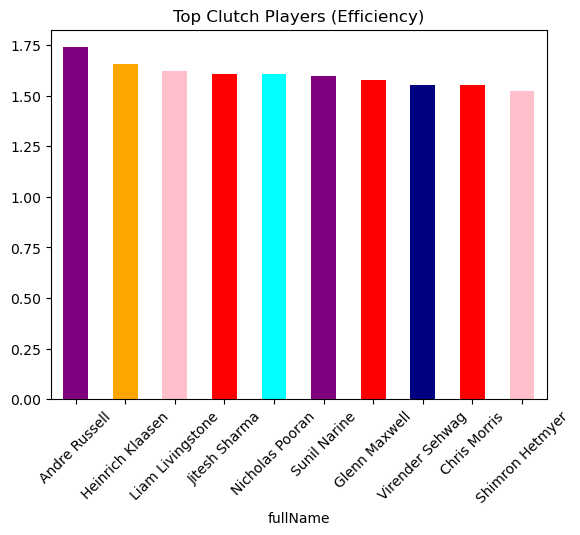

In [35]:
player_eff=df.groupby('fullName').agg(runs=('runs','sum'),ballsFaced=('ballsFaced','sum'))
player_eff['efficiency']=player_eff['runs']/player_eff['ballsFaced']
top_eff=player_eff[player_eff['runs']>500].sort_values(by='efficiency',ascending=False).head(10)
plt.figure()
top_eff['efficiency'].plot(kind='bar',color=['purple','orange','pink','red','cyan','purple','red','navy','red','pink'])
plt.title("Top Clutch Players (Efficiency)")
plt.xticks(rotation=45)
plt.show()

# Finisher Analysis (High Strike Rate Players)

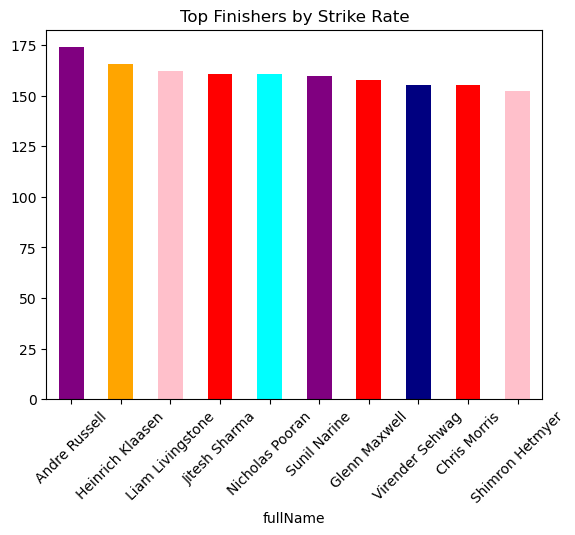

In [36]:
finishers=df.groupby('fullName').agg(runs=('runs','sum'),ballsFaced=('ballsFaced','sum'))
finishers['strikeRate']=(finishers['runs']/finishers['ballsFaced'])*100
top_finishers=finishers[finishers['runs']>500].sort_values(by='strikeRate',ascending=False).head(10)
plt.figure()
top_finishers['strikeRate'].plot(kind='bar',color=['purple','orange','pink','red','cyan','purple','red','navy','red','pink'])
plt.title("Top Finishers by Strike Rate")
plt.xticks(rotation=45)
plt.show()

# Players with Most Sixes

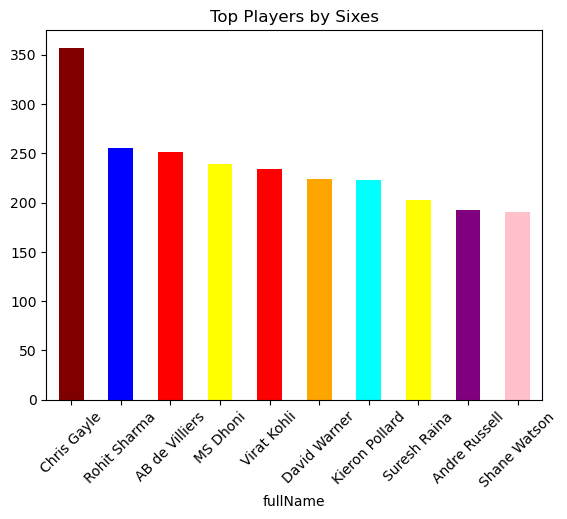

In [37]:
top_sixers=df.groupby('fullName')['sixes'].sum().sort_values(ascending=False).head(10)
plt.figure()
top_sixers.plot(kind='bar',color=['maroon','blue','red','yellow','red','orange','cyan','yellow','purple','pink'])
plt.title("Top Players by Sixes")
plt.xticks(rotation=45)
plt.show()

# Runs Distribution by Team

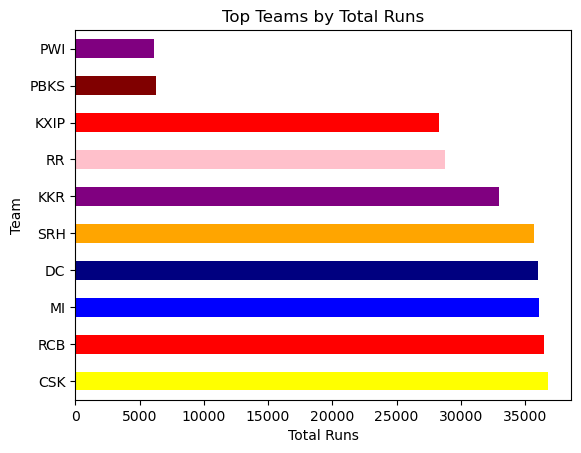

In [52]:
team_runs=df.groupby('home_team')['runs'].sum().sort_values(ascending=False)
plt.figure()
team_runs.head(10).plot(kind='barh',color=['yellow','red','blue','navy','orange','purple','pink','red','maroon','purple'])
plt.title("Top Teams by Total Runs")
plt.xlabel("Total Runs")
plt.ylabel("Team")
plt.show()

# Top Consistent Players (Low Variance)

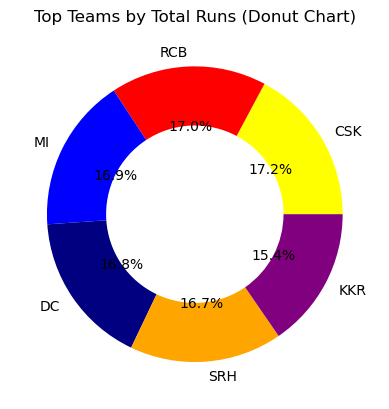

In [50]:
team_runs=df.groupby('home_team')['runs'].sum().sort_values(ascending=False)
top=team_runs.head(6)
plt.figure()
plt.pie(top.values,labels=top.index,autopct='%1.1f%%',
        colors=['yellow','red','blue','navy','orange','purple'],
        wedgeprops={'width':0.4})
plt.title("Top Teams by Total Runs (Donut Chart)")
plt.show()

# Highest Individual Scores

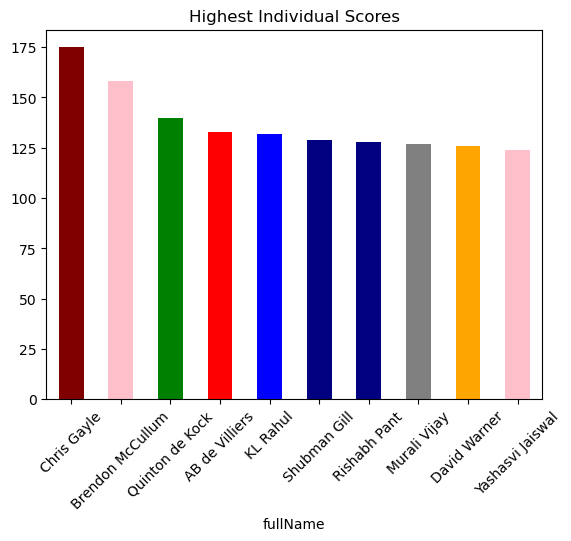

In [40]:
top_scores=df.groupby('fullName')['runs'].max().sort_values(ascending=False).head(10)
plt.figure()
top_scores.plot(kind='bar',color=['maroon','pink','green','red','blue','navy','navy','gray','orange','pink'])
plt.title("Highest Individual Scores")
plt.xticks(rotation=45)
plt.show()

# Captain with Highest Runs in a Match

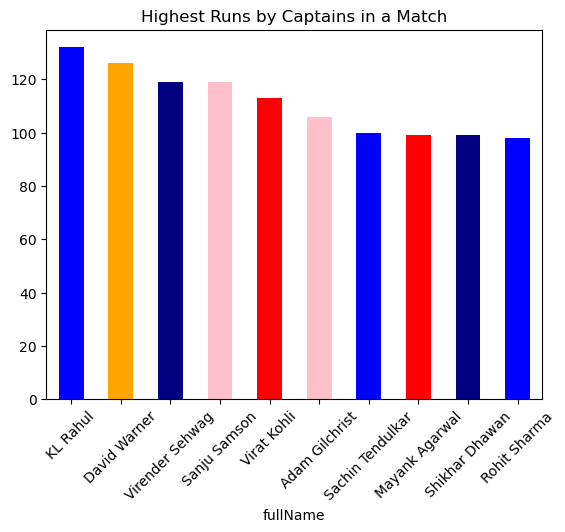

In [41]:
captain_data=df[df['captain']==True]
top_captain_score=captain_data.groupby('fullName')['runs'].max().sort_values(ascending=False).head(10)

plt.figure()
top_captain_score.plot(kind='bar',color=['blue','orange','navy','pink','red','pink','blue','red','navy','blue'])
plt.title("Highest Runs by Captains in a Match")
plt.xticks(rotation=45)
plt.show()

#  MS Dhoni Performance Visualization

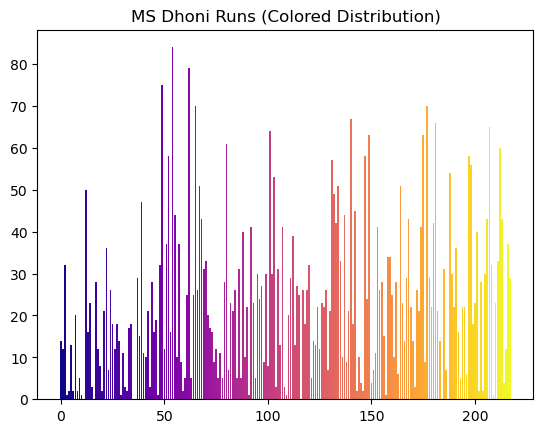

In [42]:
import numpy as np
dhoni=df[df['fullName']=="MS Dhoni"]
values=dhoni['runs']
colors=plt.cm.plasma(np.linspace(0,1,len(values)))
plt.figure()
for i in range(len(values)):
    plt.bar(i,values.iloc[i],color=colors[i])
plt.title("MS Dhoni Runs (Colored Distribution)")
plt.show()

# MS Dhoni vs Other Players

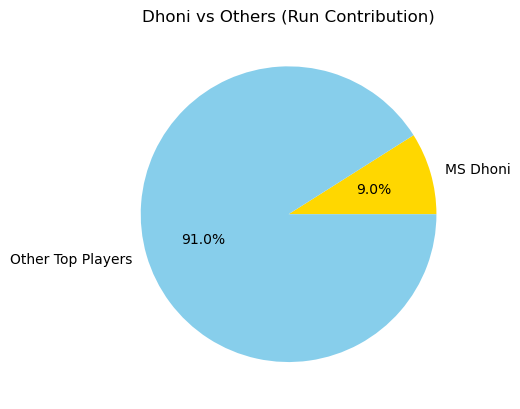

In [43]:
top_runs=top_players['runs']
top_players=df.groupby('fullName')['runs'].sum().sort_values(ascending=False).head(10)
dhoni_stats=df[df['fullName']=="MS Dhoni"].groupby('fullName')['runs'].sum()
top_runs=top_players
dhoni_run=dhoni_stats.iloc[0]
others_run=top_runs.sum()-dhoni_run
values=[dhoni_run,others_run]
labels=['MS Dhoni','Other Top Players']
colors=['gold','skyblue']
plt.figure()
plt.pie(values,labels=labels,autopct='%1.1f%%',colors=colors)
plt.title("Dhoni vs Others (Run Contribution)")
plt.show()

# most 50+ scores by a player

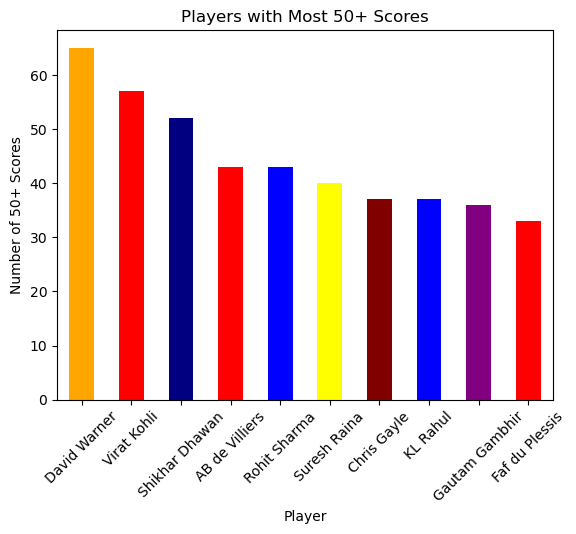

In [44]:
fifty_counts=df[df['runs']>=50].groupby('fullName')['runs'].count().sort_values(ascending=False).head(10)
plt.figure()
fifty_counts.plot(kind='bar',color=['orange','red','navy','red','blue','yellow','maroon','blue','purple','red'])
plt.title("Players with Most 50+ Scores")
plt.xlabel("Player")
plt.ylabel("Number of 50+ Scores")
plt.xticks(rotation=45)
plt.show()

# Most 100+ Scores by players

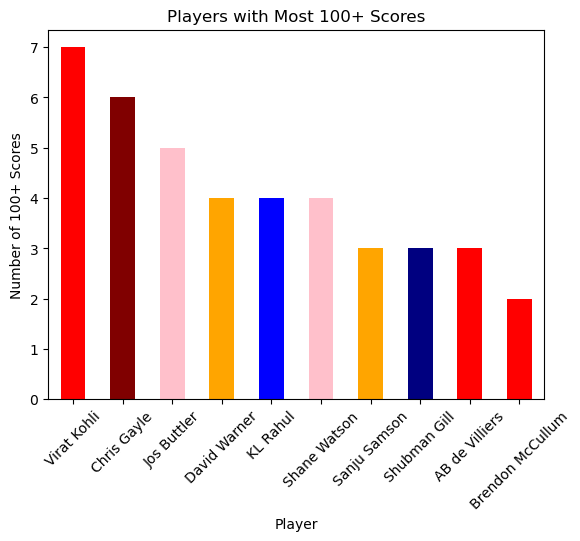

In [49]:
hundreds=df[df['runs']>=100].groupby('fullName')['runs'].count().sort_values(ascending=False).head(10)
plt.figure()
hundreds.plot(kind='bar',color=['red','maroon','pink','orange','blue','pink','orange','navy','red','red'])
plt.title("Players with Most 100+ Scores")
plt.xlabel("Player")
plt.ylabel("Number of 100+ Scores")
plt.xticks(rotation=45)
plt.show()

##  Conclusion

In this project, I performed Exploratory Data Analysis (EDA) on the IPL dataset to understand player performance, team contributions, and match patterns.

Through this analysis, I explored important aspects such as top run scorers, strike rates, boundary hitters, consistency of players, captain performances, and team-wise statistics. I also analyzed special cases like MS Dhoni’s performance and compared players based on efficiency and finishing ability.

Different types of visualizations such as bar charts, horizontal bar charts, pie charts, donut charts, histograms, scatter plots, box plots, and heatmaps were used to better understand the data and present insights clearly.

From the analysis, I observed that:
- Certain players consistently perform well across matches
- Strike rate and boundary hitting play a key role in T20 performance
- Some captains contribute significantly with both leadership and batting
- Teams differ in scoring patterns and overall performance

This project helped me improve my skills in data cleaning, handling missing values, grouping data, and creating meaningful visualizations using Pandas, Matplotlib, and Seaborn.

Overall, this analysis provided a deeper understanding of IPL data and how data-driven insights can be used to evaluate performance. This can be further extended to predictive models like match outcome prediction or player performance forecasting.